In [1]:
import os
import re
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

In [2]:
# Ganti sesuai nama dataset input Anda di Kaggle
DATASET_ROOT = Path("/kaggle/input/datasets/afenmarbun/wilddeepfake-46f")

OUTPUT_DIR = Path("/kaggle/working/eda_clips_46f")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

IMAGE_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".webp"}
EXPECTED_FRAMES_PER_CLIP = 46
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("DATASET_ROOT :", DATASET_ROOT)
print("OUTPUT_DIR   :", OUTPUT_DIR)

DATASET_ROOT : /kaggle/input/datasets/afenmarbun/wilddeepfake-46f
OUTPUT_DIR   : /kaggle/working/eda_clips_46f


In [3]:
def numeric_key(path: Path):
    """
    Mengurutkan file berdasarkan angka terakhir pada nama file.
    Cocok untuk 0.png, 1.png, 2.png, dst.
    """
    nums = re.findall(r"\d+", path.stem)
    return int(nums[-1]) if nums else path.stem


def find_subset_dirs(dataset_root: Path):
    """
    Versi robust untuk struktur dataset Anda:
    - fake_train dan fake_test ada di bawah folder archive
    - real_train dan real_test ada di bawah folder wilddeepfake_46f_merged_v5
    """
    subset_dirs = {}

    for root, dirs, files in os.walk(dataset_root):
        for d in dirs:
            if d in {"real_train", "real_test", "fake_train", "fake_test"}:
                subset_dirs[d] = Path(root) / d

    required = {"real_train", "real_test", "fake_train", "fake_test"}
    missing = required - set(subset_dirs.keys())

    if missing:
        print("Folder yang berhasil ditemukan:")
        for k, v in subset_dirs.items():
            print(f"- {k}: {v}")
        raise FileNotFoundError(
            f"Folder subset berikut tidak ditemukan: {sorted(missing)}\n"
            f"Periksa kembali struktur dataset di: {dataset_root}"
        )

    return subset_dirs


def list_image_files(folder: Path):
    return sorted(
        [p for p in folder.iterdir() if p.is_file() and p.suffix.lower() in IMAGE_EXTS],
        key=numeric_key
    )


def collect_clip_dirs(subset_dir: Path):
    """
    Leaf folder yang berisi file gambar dianggap sebagai satu klip.
    """
    clip_dirs = []

    for root, dirs, files in os.walk(subset_dir):
        image_files = [f for f in files if Path(f).suffix.lower() in IMAGE_EXTS]
        if image_files:
            clip_dirs.append(Path(root))

    return sorted(clip_dirs)

In [4]:
subset_dirs = find_subset_dirs(DATASET_ROOT)

print("Subset ditemukan:")
for k, v in subset_dirs.items():
    print(f"- {k:10s}: {v}")


records = []

for subset_name, subset_dir in subset_dirs.items():
    clip_dirs = collect_clip_dirs(subset_dir)

    split = "train" if subset_name.endswith("train") else "test"
    label = "real" if subset_name.startswith("real") else "fake"

    for clip_dir in clip_dirs:
        frame_files = list_image_files(clip_dir)
        num_frames = len(frame_files)

        archive_group = clip_dir.parent.name if clip_dir.parent != subset_dir else None
        clip_name = clip_dir.name

        first_frame = frame_files[0].name if num_frames > 0 else None
        last_frame = frame_files[-1].name if num_frames > 0 else None

        frame_indices = []
        for fp in frame_files:
            nums = re.findall(r"\d+", fp.stem)
            frame_indices.append(int(nums[-1]) if nums else np.nan)

        min_frame_idx = np.nanmin(frame_indices) if len(frame_indices) > 0 else np.nan
        max_frame_idx = np.nanmax(frame_indices) if len(frame_indices) > 0 else np.nan

        records.append({
            "subset": subset_name,
            "split": split,
            "label": label,
            "archive_group": archive_group,
            "clip_name": clip_name,
            "clip_dir": str(clip_dir),
            "num_frames": num_frames,
            "is_valid_46": num_frames == EXPECTED_FRAMES_PER_CLIP,
            "first_frame_file": first_frame,
            "last_frame_file": last_frame,
            "min_frame_idx": min_frame_idx,
            "max_frame_idx": max_frame_idx,
        })

df_clips = pd.DataFrame(records)

print(f"\nJumlah total klip yang terdeteksi: {len(df_clips):,}")
df_clips.head()

Subset ditemukan:
- real_train: /kaggle/input/datasets/afenmarbun/wilddeepfake-46f/wilddeepfake_46f_merged_v5/real_train
- real_test : /kaggle/input/datasets/afenmarbun/wilddeepfake-46f/wilddeepfake_46f_merged_v5/real_test
- fake_test : /kaggle/input/datasets/afenmarbun/wilddeepfake-46f/archive/fake_test
- fake_train: /kaggle/input/datasets/afenmarbun/wilddeepfake-46f/archive/fake_train

Jumlah total klip yang terdeteksi: 22,303


,subset,split,label,archive_group,clip_name,clip_dir,num_frames,is_valid_46,first_frame_file,last_frame_file,min_frame_idx,max_frame_idx
0,real_train,train,real,1,103_0,/kaggle/input/datasets/afenmarbun/wilddeepfake...,46,True,650.png,695.png,650,695
1,real_train,train,real,1,175_0,/kaggle/input/datasets/afenmarbun/wilddeepfake...,46,True,1261.png,1306.png,1261,1306
2,real_train,train,real,1,318_0,/kaggle/input/datasets/afenmarbun/wilddeepfake...,46,True,2003.png,2048.png,2003,2048
3,real_train,train,real,1,506_0,/kaggle/input/datasets/afenmarbun/wilddeepfake...,46,True,3737.png,3782.png,3737,3782
4,real_train,train,real,1,619_0,/kaggle/input/datasets/afenmarbun/wilddeepfake...,46,True,4366.png,4411.png,4366,4411


In [5]:
print("Ringkasan umum")
print(df_clips[["subset", "split", "label", "num_frames", "is_valid_46"]].head())

summary_overall = pd.DataFrame({
    "jumlah_klip": [len(df_clips)],
    "jumlah_klip_valid_46": [int(df_clips["is_valid_46"].sum())],
    "jumlah_klip_tidak_valid": [int((~df_clips["is_valid_46"]).sum())],
    "rata_rata_frame_per_klip": [df_clips["num_frames"].mean()],
    "median_frame_per_klip": [df_clips["num_frames"].median()],
    "minimum_frame_per_klip": [df_clips["num_frames"].min()],
    "maksimum_frame_per_klip": [df_clips["num_frames"].max()],
})

summary_overall

Ringkasan umum
       subset  split label  num_frames  is_valid_46
0  real_train  train  real          46         True
1  real_train  train  real          46         True
2  real_train  train  real          46         True
3  real_train  train  real          46         True
4  real_train  train  real          46         True


,jumlah_klip,jumlah_klip_valid_46,jumlah_klip_tidak_valid,rata_rata_frame_per_klip,median_frame_per_klip,minimum_frame_per_klip,maksimum_frame_per_klip
0,22303,22303,0,46.0,46.0,46,46


In [6]:
summary_subset = (
    df_clips
    .groupby(["subset", "split", "label"], as_index=False)
    .agg(
        jumlah_klip=("clip_dir", "count"),
        jumlah_klip_valid_46=("is_valid_46", "sum"),
        rata_rata_frame=("num_frames", "mean"),
        median_frame=("num_frames", "median"),
        minimum_frame=("num_frames", "min"),
        maksimum_frame=("num_frames", "max"),
    )
    .sort_values(["split", "label", "subset"])
)

summary_subset

,subset,split,label,jumlah_klip,jumlah_klip_valid_46,rata_rata_frame,median_frame,minimum_frame,maksimum_frame
0,fake_test,test,fake,2139,2139,46.0,46.0,46,46
2,real_test,test,real,1093,1093,46.0,46.0,46,46
1,fake_train,train,fake,12313,12313,46.0,46.0,46,46
3,real_train,train,real,6758,6758,46.0,46.0,46,46


In [7]:
frame_count_distribution = (
    df_clips["num_frames"]
    .value_counts()
    .sort_index()
    .reset_index()
)
frame_count_distribution.columns = ["num_frames", "jumlah_klip"]
frame_count_distribution

,num_frames,jumlah_klip
0,46,22303


In [8]:
df_clips.to_csv(OUTPUT_DIR / "manifest_klip_46f.csv", index=False)
summary_overall.to_csv(OUTPUT_DIR / "summary_overall.csv", index=False)
summary_subset.to_csv(OUTPUT_DIR / "summary_per_subset.csv", index=False)
frame_count_distribution.to_csv(OUTPUT_DIR / "distribusi_num_frames.csv", index=False)

print("CSV berhasil disimpan di:")
for p in sorted(OUTPUT_DIR.glob("*.csv")):
    print("-", p)

CSV berhasil disimpan di:
- /kaggle/working/eda_clips_46f/distribusi_num_frames.csv
- /kaggle/working/eda_clips_46f/manifest_klip_46f.csv
- /kaggle/working/eda_clips_46f/summary_overall.csv
- /kaggle/working/eda_clips_46f/summary_per_subset.csv


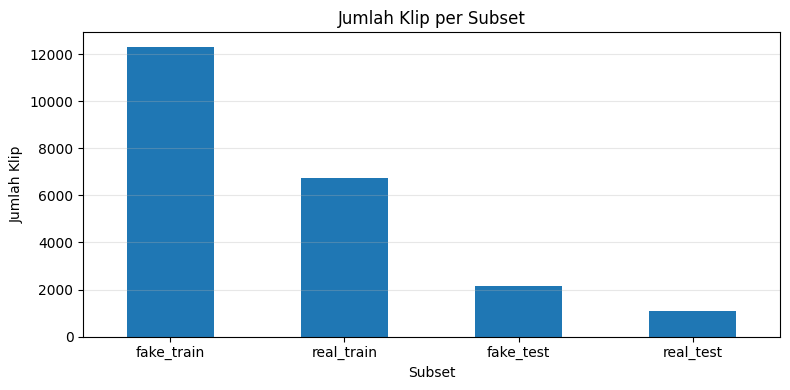

In [9]:
plot_df = (
    df_clips.groupby("subset")["clip_dir"]
    .count()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 4))
plot_df.plot(kind="bar")
plt.title("Jumlah Klip per Subset")
plt.xlabel("Subset")
plt.ylabel("Jumlah Klip")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

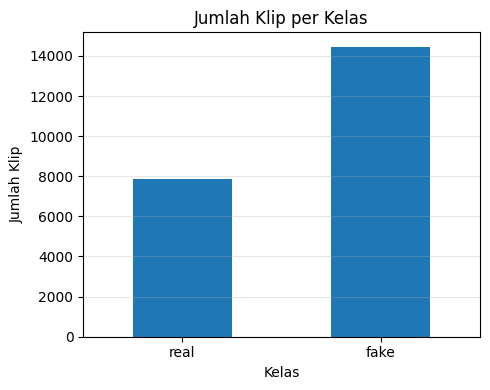

In [10]:
plot_df = (
    df_clips.groupby("label")["clip_dir"]
    .count()
    .reindex(["real", "fake"])
)

plt.figure(figsize=(5, 4))
plot_df.plot(kind="bar")
plt.title("Jumlah Klip per Kelas")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Klip")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
validity_counts = df_clips["is_valid_46"].value_counts().rename(index={True: "valid_46", False: "tidak_valid"})
validity_counts

is_valid_46
valid_46    22303
Name: count, dtype: int64

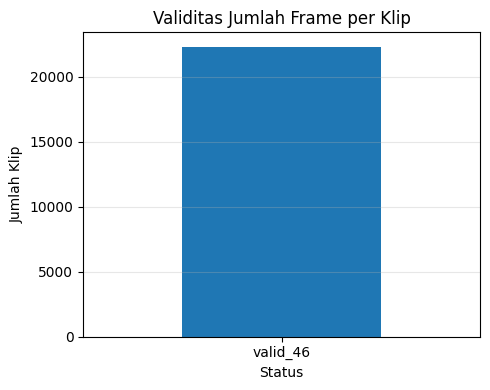

In [12]:
plt.figure(figsize=(5, 4))
validity_counts.plot(kind="bar")
plt.title("Validitas Jumlah Frame per Klip")
plt.xlabel("Status")
plt.ylabel("Jumlah Klip")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

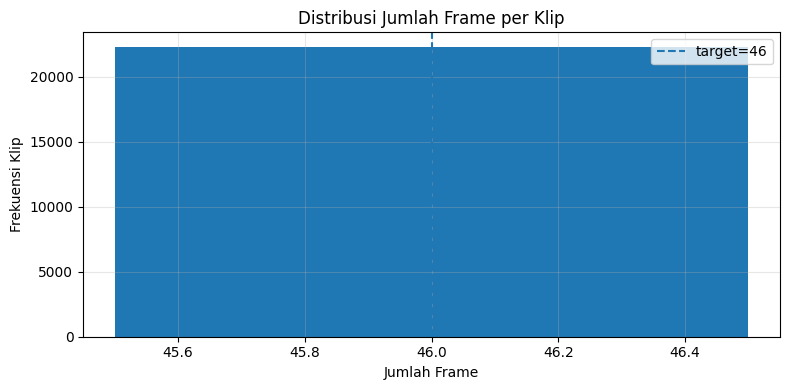

In [13]:
plt.figure(figsize=(8, 4))
plt.hist(df_clips["num_frames"], bins=min(30, df_clips["num_frames"].nunique()))
plt.axvline(EXPECTED_FRAMES_PER_CLIP, linestyle="--", label=f"target={EXPECTED_FRAMES_PER_CLIP}")
plt.title("Distribusi Jumlah Frame per Klip")
plt.xlabel("Jumlah Frame")
plt.ylabel("Frekuensi Klip")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
invalid_clips = df_clips.loc[~df_clips["is_valid_46"]].copy()

print(f"Jumlah klip tidak valid: {len(invalid_clips):,}")
invalid_clips.head(20)

Jumlah klip tidak valid: 0


,subset,split,label,archive_group,clip_name,clip_dir,num_frames,is_valid_46,first_frame_file,last_frame_file,min_frame_idx,max_frame_idx


In [15]:
def check_frame_index_continuity(clip_dir_str):
    clip_dir = Path(clip_dir_str)
    frame_files = list_image_files(clip_dir)

    frame_indices = []
    for fp in frame_files:
        nums = re.findall(r"\d+", fp.stem)
        frame_indices.append(int(nums[-1]) if nums else np.nan)

    frame_indices = np.array(frame_indices, dtype=float)

    if len(frame_indices) == 0 or np.isnan(frame_indices).any():
        return False, None

    diffs = np.diff(frame_indices)
    is_non_decreasing = np.all(diffs >= 0)

    return is_non_decreasing, diffs.tolist()


valid_sample = df_clips[df_clips["is_valid_46"]].sample(min(10, len(df_clips[df_clips["is_valid_46"]])), random_state=RANDOM_SEED)

continuity_records = []
for _, row in valid_sample.iterrows():
    ok, diffs = check_frame_index_continuity(row["clip_dir"])
    continuity_records.append({
        "clip_dir": row["clip_dir"],
        "subset": row["subset"],
        "label": row["label"],
        "non_decreasing_index": ok,
    })

pd.DataFrame(continuity_records)

,clip_dir,subset,label,non_decreasing_index
0,/kaggle/input/datasets/afenmarbun/wilddeepfake...,fake_test,fake,True
1,/kaggle/input/datasets/afenmarbun/wilddeepfake...,fake_train,fake,True
2,/kaggle/input/datasets/afenmarbun/wilddeepfake...,real_train,real,True
3,/kaggle/input/datasets/afenmarbun/wilddeepfake...,fake_test,fake,True
4,/kaggle/input/datasets/afenmarbun/wilddeepfake...,fake_train,fake,True
5,/kaggle/input/datasets/afenmarbun/wilddeepfake...,fake_train,fake,True
6,/kaggle/input/datasets/afenmarbun/wilddeepfake...,fake_train,fake,True
7,/kaggle/input/datasets/afenmarbun/wilddeepfake...,real_train,real,True
8,/kaggle/input/datasets/afenmarbun/wilddeepfake...,real_train,real,True
9,/kaggle/input/datasets/afenmarbun/wilddeepfake...,fake_train,fake,True


In [16]:
def show_clip_triplet(clip_dir_str, title=None):
    clip_dir = Path(clip_dir_str)
    frame_files = list_image_files(clip_dir)

    if len(frame_files) == 0:
        print(f"Tidak ada frame di {clip_dir}")
        return

    idx_first = 0
    idx_mid = len(frame_files) // 2
    idx_last = len(frame_files) - 1

    chosen = [frame_files[idx_first], frame_files[idx_mid], frame_files[idx_last]]
    labels = ["awal", "tengah", "akhir"]

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    for ax, fp, lab in zip(axes, chosen, labels):
        with Image.open(fp) as img:
            ax.imshow(img.convert("RGB"))
        ax.set_title(f"{lab}\n{fp.name}")
        ax.axis("off")

    plt.suptitle(title if title else clip_dir.name)
    plt.tight_layout()
    plt.show()


sample_examples = (
    df_clips[df_clips["is_valid_46"]]
    .groupby(["subset"], group_keys=False)
    .apply(lambda x: x.sample(min(1, len(x)), random_state=RANDOM_SEED))
)

sample_examples[["subset", "label", "clip_dir"]]

,subset,label,clip_dir
7921,fake_test,fake,/kaggle/input/datasets/afenmarbun/wilddeepfake...
15630,fake_train,fake,/kaggle/input/datasets/afenmarbun/wilddeepfake...
7240,real_test,real,/kaggle/input/datasets/afenmarbun/wilddeepfake...
828,real_train,real,/kaggle/input/datasets/afenmarbun/wilddeepfake...


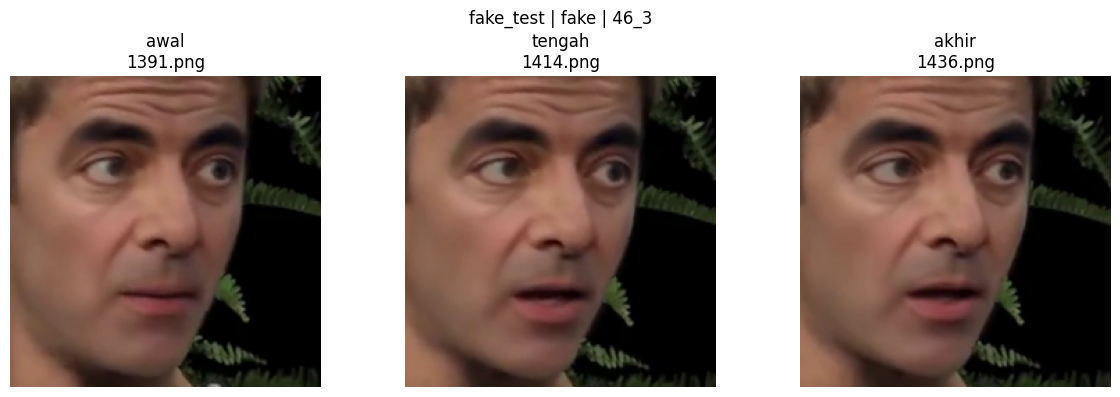

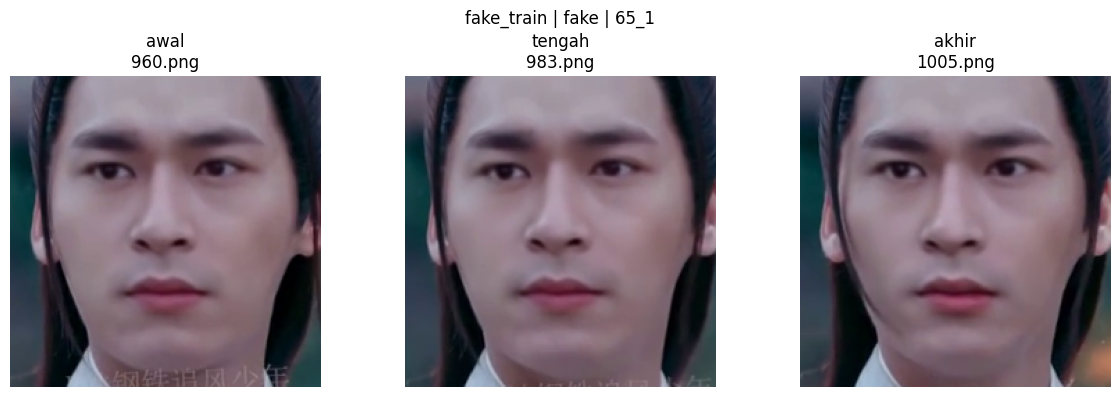

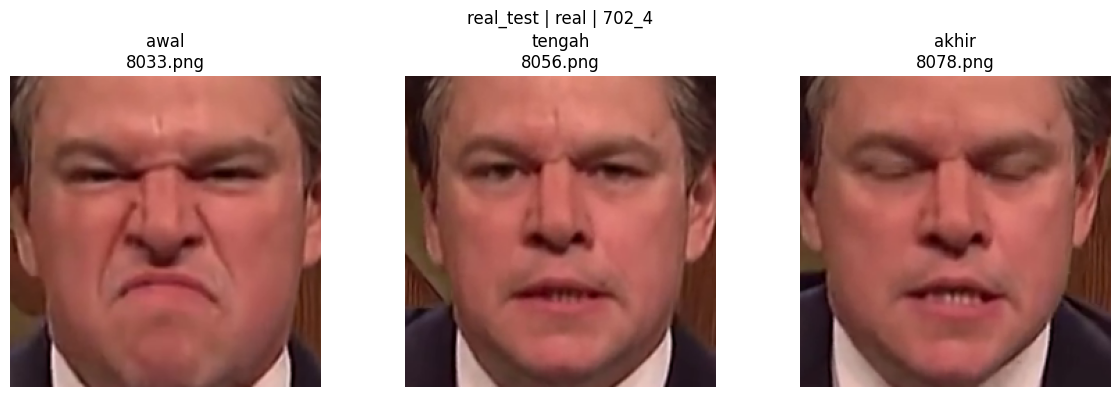

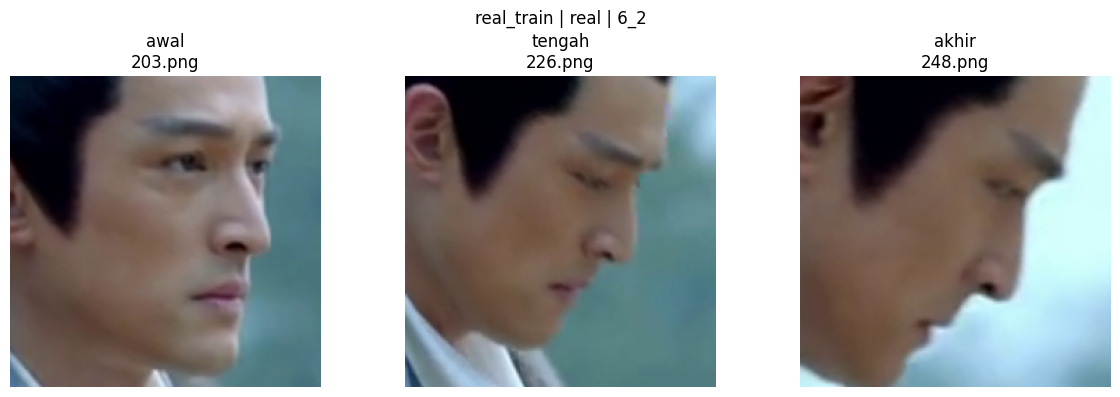

In [17]:
for _, row in sample_examples.iterrows():
    show_clip_triplet(
        row["clip_dir"],
        title=f"{row['subset']} | {row['label']} | {Path(row['clip_dir']).name}"
    )

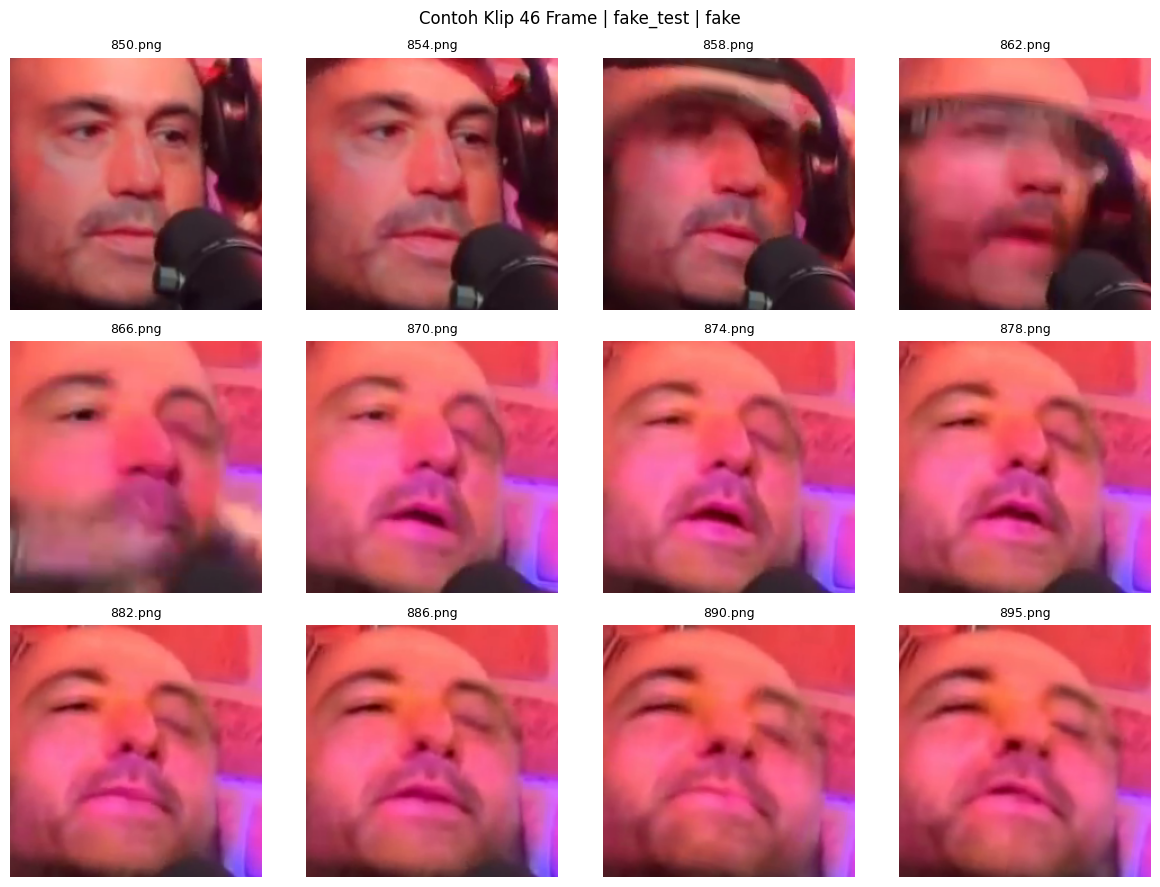

In [18]:
def show_clip_grid(clip_dir_str, n_frames=12, title=None):
    clip_dir = Path(clip_dir_str)
    frame_files = list_image_files(clip_dir)

    if len(frame_files) == 0:
        print(f"Tidak ada frame di {clip_dir}")
        return

    n_frames = min(n_frames, len(frame_files))
    idx = np.linspace(0, len(frame_files) - 1, n_frames, dtype=int)
    selected = [frame_files[i] for i in idx]

    cols = 4
    rows = int(np.ceil(n_frames / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(12, 3 * rows))
    axes = np.array(axes).reshape(-1)

    for ax, fp in zip(axes, selected):
        with Image.open(fp) as img:
            ax.imshow(img.convert("RGB"))
        ax.set_title(fp.name, fontsize=9)
        ax.axis("off")

    for ax in axes[len(selected):]:
        ax.axis("off")

    plt.suptitle(title if title else clip_dir.name)
    plt.tight_layout()
    plt.show()


example_clip = df_clips[df_clips["is_valid_46"]].sample(1, random_state=RANDOM_SEED).iloc[0]
show_clip_grid(
    example_clip["clip_dir"],
    n_frames=12,
    title=f"Contoh Klip 46 Frame | {example_clip['subset']} | {example_clip['label']}"
)

In [19]:
jumlah_total_klip = len(df_clips)
jumlah_valid = int(df_clips["is_valid_46"].sum())
jumlah_invalid = int((~df_clips["is_valid_46"]).sum())

print("RINGKASAN AKHIR EDA")
print(f"- Jumlah total klip           : {jumlah_total_klip:,}")
print(f"- Jumlah klip valid 46 frame  : {jumlah_valid:,}")
print(f"- Jumlah klip tidak valid     : {jumlah_invalid:,}")
print(f"- Rata-rata frame per klip    : {df_clips['num_frames'].mean():.2f}")
print(f"- Median frame per klip       : {df_clips['num_frames'].median():.2f}")
print(f"- Minimum frame per klip      : {df_clips['num_frames'].min()}")
print(f"- Maksimum frame per klip     : {df_clips['num_frames'].max()}")

RINGKASAN AKHIR EDA
- Jumlah total klip           : 22,303
- Jumlah klip valid 46 frame  : 22,303
- Jumlah klip tidak valid     : 0
- Rata-rata frame per klip    : 46.00
- Median frame per klip       : 46.00
- Minimum frame per klip      : 46
- Maksimum frame per klip     : 46
